# Machine Learning Project
## Library imports

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RANSACRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split   

## Data Importation 

In [155]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')

## DataFrame Creation

It will be easier for data visualization to work with pandas dataframes

In [156]:
# Features's Names
column_names_X = ['air_tmp','water_tmp','wind_speed','wind_dir','illumination']
column_names_y = ['toxic_concentration']
column_names_X_test = ['air_tmp','water_tmp','wind_speed','wind_dir','illumination']

# Creating DataFrames
df_X_train = pd.DataFrame(X_train)
df_y_train = pd.DataFrame(y_train)
df_X_test = pd.DataFrame(X_test)

# Attributing Column Names
df_X_train.columns = column_names_X
df_y_train.columns = column_names_y
df_X_test.columns = column_names_X_test

## Data Visualization

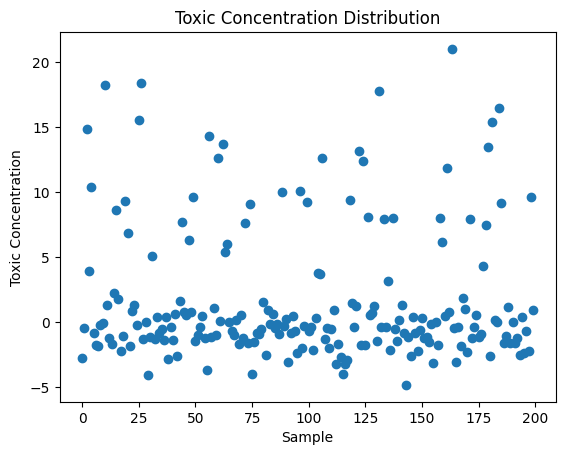

In [157]:
plt.scatter(range(0,200), y_train)
plt.title('Toxic Concentration Distribution')
plt.ylabel('Toxic Concentration')   
plt.xlabel('Sample')
plt.show()

Text(0.5, 0, 'Features')

<Figure size 1000x1000 with 0 Axes>

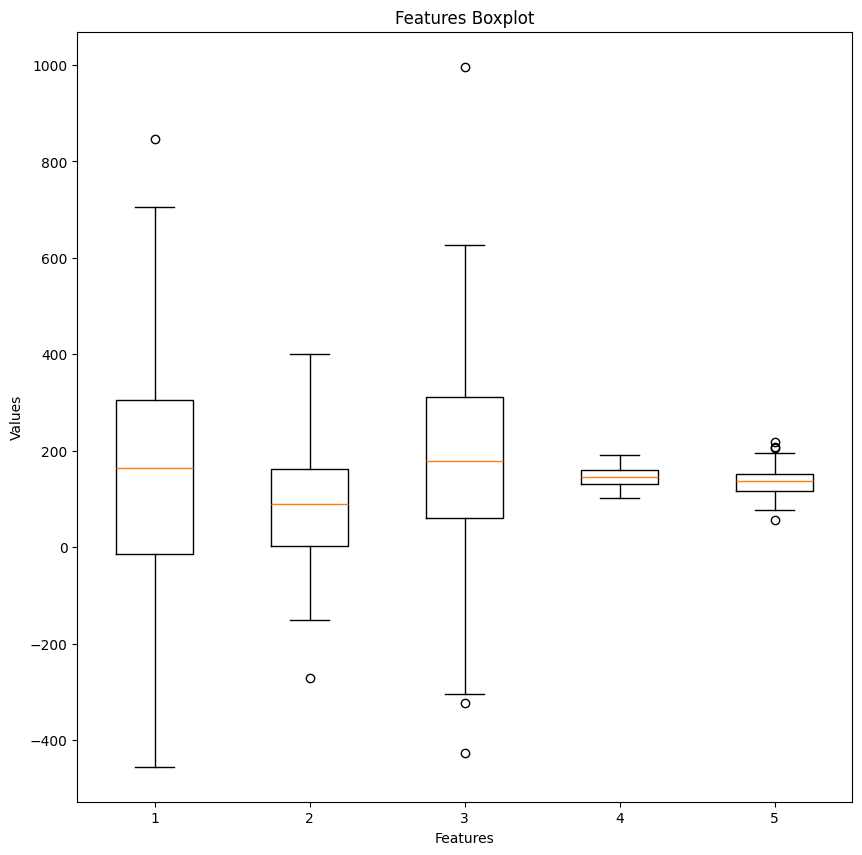

In [158]:
#boxplot of the features
plt.figure(figsize=(10,10))
# Boxplot of the features
plt.figure(figsize=(10,10))
plt.boxplot(X_train)
plt.title('Features Boxplot')
plt.ylabel('Values')
plt.xlabel('Features')

The points we can see on the boxplots are the outlier values of the features.

## Correlation between features

We create a new data DataFrame for plotting the correlation heatmap:

We can observe a correlation between illumination and air temperature and between illumination and water temperature. The other pairs are not correlate exept for the wind direction and speed. 
$\newline$ Water and air temperatures increase when the illumination is higher.

## Linear Regression - With Outliers

In [159]:
# Let's start the linear regression
lm = LinearRegression()
model = lm.fit(X_train, y_train)
print(f"\t y = {model.intercept_:.4f} + {model.coef_[0]:.4f}x_1 + {model.coef_[1]:.4f}x_2 + {model.coef_[2]:.4f}x_3 + {model.coef_[3]:.4f}x_4 + {model.coef_[4]:.4f}x_5")

	 y = -33.0704 + -0.0211x_1 + -0.0891x_2 + -0.0006x_3 + -0.0355x_4 + 0.3774x_5


Our linear regression model is : $\newline$ 
$$y = \beta_0 + \beta_1x_{1} + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 + \beta_5x_5$$

$$y = -33.0704 + -0.0211 \times x_{1} + -0.0891 \times x_2 + -0.0006 \times x_3 + -0.0355 \times x_4 + 0.3774 \times x_5$$

We can see that $\beta_3$ is very low so we could try to delete $x_3$ from our model to improve time computation while having the same acurracy.

### Predictions

We are going to make the predicitons and compare them with the train set and square the result so that we will have the cuadratic loss  

Text(0.5, 1.0, 'Real x Predicted')

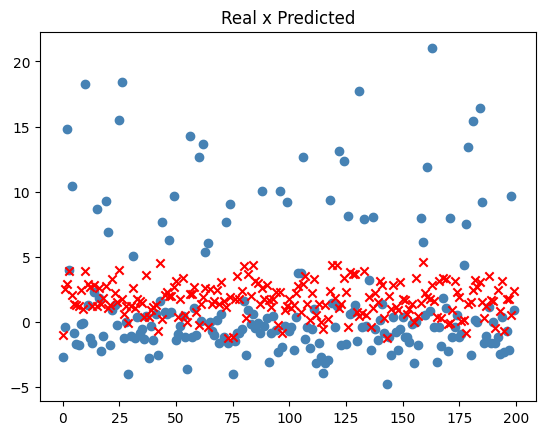

In [160]:
y_train_pred = model.predict(X_train)
plt.scatter(range(0,200), y_train, color='steelblue', marker='o', label='Real')
plt.scatter(range(0,200), y_train_pred, color='red', marker='x', label='Predicted')
plt.title('Real x Predicted')

Most of the predictions aren't good. 

Let's measure the SSE :

Sum of squares error mean : 25.020208183362055
0.060559944384204645


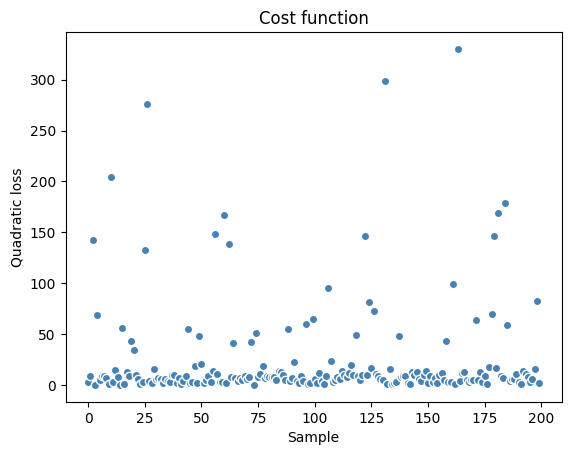

In [161]:
quadratic_loss = (y_train_pred - y_train)**2

plt.scatter(range(0,200), quadratic_loss, c='steelblue', marker='o',
            edgecolor='white', label='Entrenamiento')

plt.title('Cost function')
plt.ylabel('Quadratic loss')
plt.xlabel('Sample')

print("Sum of squares error mean :", mean_squared_error(y_train, y_train_pred))
print(r2_score(y_train, y_train_pred)) #coefficient of determination = 1-SSE/standard deviation 

Our first approach of the model is not working very well. As we see in the cost plot, there are big errors in some samples. The coefficient of determination whose best value, 1, is achieved when SSE=0 (no erros), is too low.  Therefore, our goal is to remove those conflicting samples and to meassure the performance of the model again.

### Residuals

Let's study the residuals in order to identify the outliers.

Text(0.5, 0, 'Real')

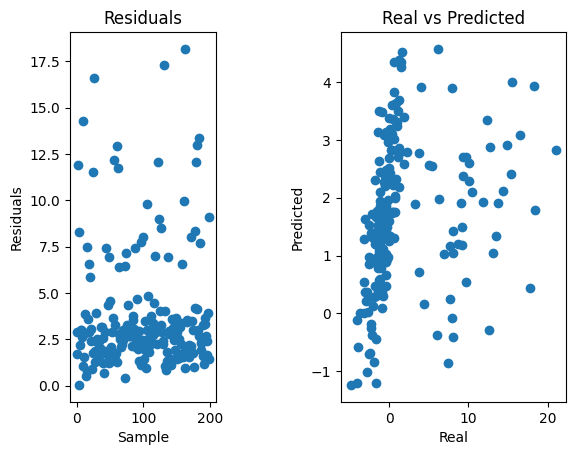

In [162]:
residuals = np.abs(y_train - y_train_pred)
plt.subplot(1,3,1)
plt.scatter(range(0,200),residuals)
plt.title('Residuals')
plt.ylabel('Residuals') 
plt.xlabel('Sample')

plt.subplot(1,2,2)
plt.scatter(y_train, y_train_pred)
plt.title('Real vs Predicted')
plt.ylabel('Predicted') 
plt.xlabel('Real')

Text(0.5, 0, 'Residuals')

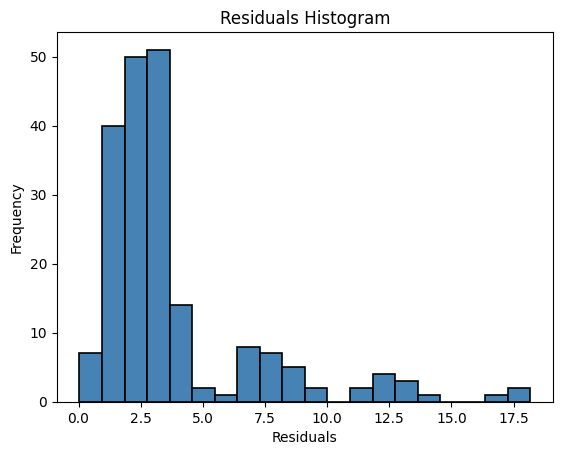

In [163]:
plt.hist(residuals, bins=20, color='steelblue', edgecolor='black', linewidth=1.2)
plt.title('Residuals Histogram')
plt.ylabel('Frequency')
plt.xlabel('Residuals')

We know that approximately 25% of the measurements are incorrect, and we observe four Gaussian distributions in the histogram. The first one likely corresponds to the correct measurements, while the others represent the incorrect ones.

Now, how many samples have residuals greater than 5?

In [164]:
res_g5 = residuals[residuals > 5]
print(f"Residuals greater than 5: {len(res_g5)}")

Residuals greater than 5: 36


The number of outliers considering that their residuals must me over 5 is 36.

## Finding and removing the outliers

### Three Sigma Rule

The "sigma edit rule" rule is a measure of the outlyingness of an observation $x_i$. The "three sigma edit" rule is defined as : 
$$t_i = \frac{x_i - \bar{x}}{s}$$

If $ |t_{i}| > 3$ then the observation is considered as "suspicious".

In [165]:
# The meaning and the standard error of the features
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals)

# Create a mask for the outliers
outliers_mask = np.abs((residuals - mean_residuals) / std_residuals) > 3

# Number of outliers    
print(f"Number of outliers : {outliers_mask.sum()}")

Number of outliers : 4


### Median absolute deviation about the median

The median absolute deviation about the median is the median of the absolute distance from the median is defined as :

$$MAD(\bold{x}) = Med\space\{|1-Med(\bold{x})|\}$$

The threshold of this method is $k \times MAD$,

with $k = \frac{\hat{\sigma}}{MAD}$, a constant coefficient. $k$ is choosen according to the sensitiviness we want our threshold to be. Commonly $k = 3$.

MAD:  0.9099301658650075
k:  3.5910060515418967
Number of outliers using MAD: 35


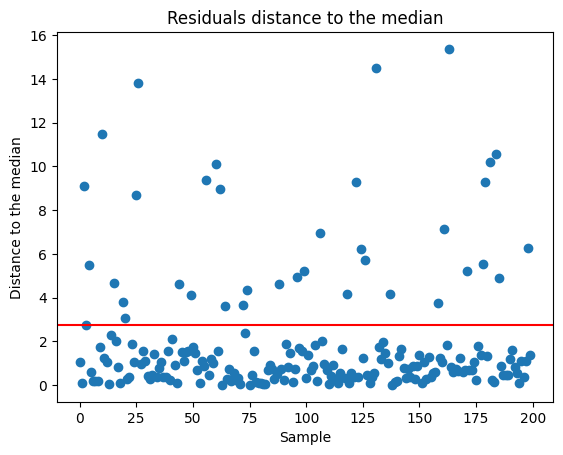

In [166]:
mad_residuals = np.median(np.abs(residuals - np.median(residuals)))
print("MAD: ", mad_residuals)

# sensitivity factor
k = std_residuals/ mad_residuals
print("k: ", k)

#finding the outliers using the median absolute deviation
outliers_mask_mad = np.abs(residuals - np.median(residuals)) > k * mad_residuals

print("Number of outliers using MAD:", outliers_mask_mad.sum())

# plot of the distance of the residuals to the median
plt.scatter(range(0,200),np.abs(residuals - np.median(residuals)))
plt.title('Residuals distance to the median')
plt.axhline(y=3*mad_residuals, color='r', linestyle='-')
plt.ylabel('Distance to the median')
plt.xlabel('Sample')
plt.show()

With this method we find almost the same number of outliers as before with the histogram.

### Remoiving the outliers

In [167]:
# Removing the outliers using MAD
X_train_clean = X_train[~outliers_mask_mad]
y_train_clean = y_train[~outliers_mask_mad]

np.shape(X_train_clean)

(165, 5)

## Second Model - Without Outliers

### Creation of a validation set
Now that we have our clean dataset let's devide it into a training set and a validation set :

In [168]:
#splitting the data
X_train_clean, X_val, y_train_clean, y_val = train_test_split(X_train_clean, y_train_clean, test_size=0.2, random_state=0)

### Linear Regression

In [169]:
# Let's start the linear regression
lm = LinearRegression()
model = lm.fit(X_train_clean, y_train_clean)
print(f"\t y = {model.intercept_:.4f} + {model.coef_[0]:.4f}x_1 + {model.coef_[1]:.4f}x_2 + {model.coef_[2]:.4f}x_3 + {model.coef_[3]:.4f}x_4 + {model.coef_[4]:.4f}x_5")

	 y = -4.9634 + -0.0075x_1 + -0.0247x_2 + -0.0004x_3 + -0.0130x_4 + 0.0725x_5


### Predictions

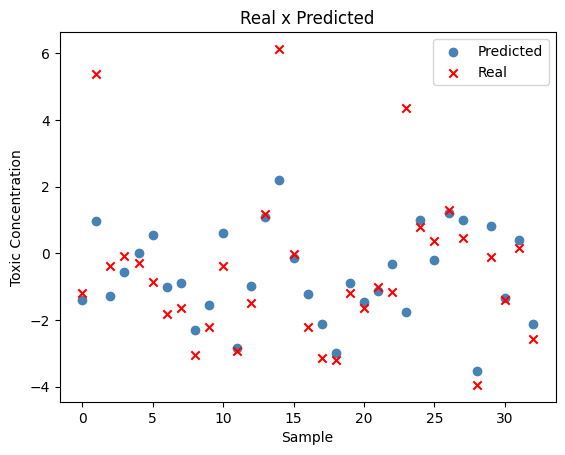

In [170]:
y_val_pred = model.predict(X_val)
plt.scatter(range(0,np.shape(y_val_pred)[0]), y_val_pred, color='steelblue', marker='o', label='Predicted')
plt.scatter(range(0,np.shape(y_val)[0]), y_val, color='red', marker='x', label='Real')
plt.title('Real x Predicted')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')    
plt.legend(loc='upper right')   

As we can see, the predictions are almost identical to the actual values. Let's study the residuals : 

### Residuals

Sum of squares error mean : 2.52988328716418


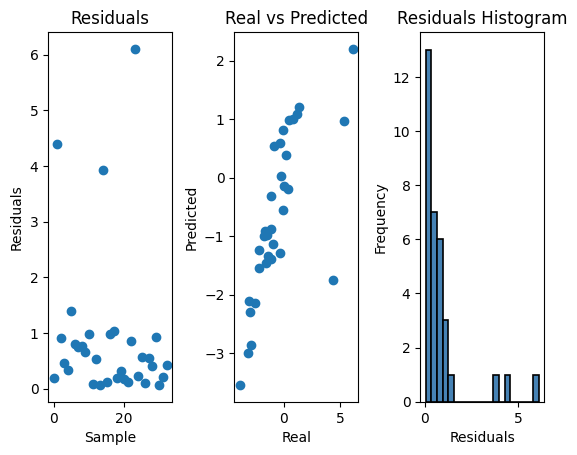

In [171]:
residuals = np.abs(y_val - y_val_pred)
plt.subplot(1,3,1)
plt.scatter(range(0,np.shape(residuals)[0]),residuals)
plt.title('Residuals')
plt.ylabel('Residuals') 
plt.xlabel('Sample')

plt.subplot(1,3,2)
plt.scatter(y_val, y_val_pred)
plt.title('Real vs Predicted')
plt.ylabel('Predicted') 
plt.xlabel('Real')

plt.subplot(1,3,3)
plt.hist(residuals, bins=20, color='steelblue', edgecolor='black', linewidth=1.2)
plt.title('Residuals Histogram')
plt.ylabel('Frequency')
plt.xlabel('Residuals')
plt.subplots_adjust(wspace=0.5)

print("Sum of squares error mean :", mean_squared_error(y_val, y_val_pred))
plt.show()


As we can see, the SSE is significantly lower than before. However, we could potentially enhance the model further by applying regularization techniques.

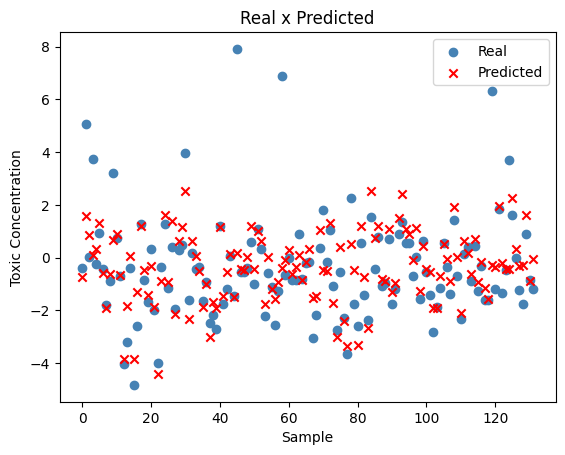

Sum of squares error mean : 1.9471081520840328


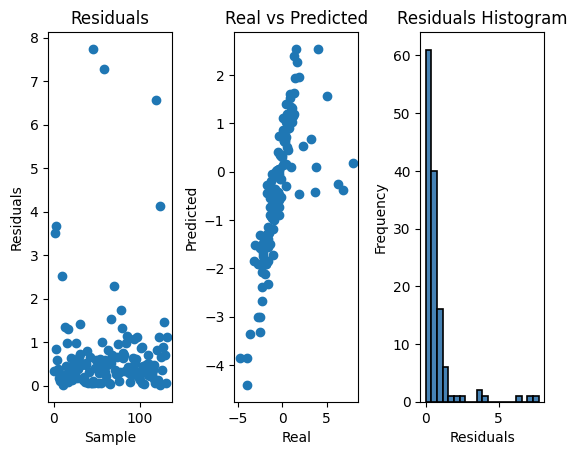

In [172]:
y_clean_pred = model.predict(X_train_clean)
plt.scatter(range(0,np.shape(y_train_clean)[0]), y_train_clean, color='steelblue', marker='o', label='Real')
plt.scatter(range(0,np.shape(y_train_clean)[0]), y_clean_pred, color='red', marker='x', label='Predicted')
plt.title('Real x Predicted')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')
plt.legend(loc='upper right')
plt.show()

residuals = np.abs(y_train_clean - y_clean_pred)
plt.subplot(1,3,1)
plt.scatter(range(0,np.shape(residuals)[0]),residuals)
plt.title('Residuals')
plt.ylabel('Residuals')
plt.xlabel('Sample')

plt.subplot(1,3,2)
plt.scatter(y_train_clean, y_clean_pred)
plt.title('Real vs Predicted')
plt.ylabel('Predicted')
plt.xlabel('Real')

plt.subplot(1,3,3)
plt.hist(residuals, bins=20, color='steelblue', edgecolor='black', linewidth=1.2)
plt.title('Residuals Histogram')
plt.ylabel('Frequency')
plt.xlabel('Residuals')
plt.subplots_adjust(wspace=0.5)

print("Sum of squares error mean :", mean_squared_error(y_train_clean, y_clean_pred))
plt.show()

The SSE decreased, but not significantly because the outliers in a such way that they remain unnoticed. 

We are now gonna use regularization methods in order to improve the performance of our linear model

## Regularization techniques

### L1 Regularization

Let's try Lasso Regularization :

Sum of squares error mean : 2.5002203394596147
Performance =  0.5112274851031495
Number of features after regularization = 5 
[-0.00419365 -0.00867829 -0.00044746 -0.01272298  0.00136052]


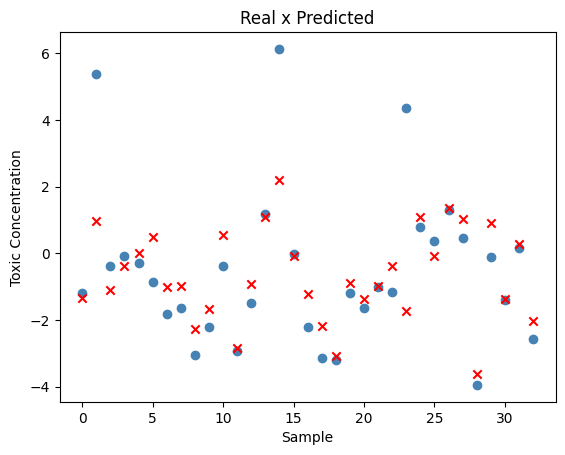

In [173]:
# Model creation
L1 = Lasso(alpha=0.1)

# Model training
L1.fit(X_train_clean, y_train_clean)

# Prediction ingoring atypical samples
y_l1_pred = L1.predict(X_val)

plt.scatter(range(0,np.shape(y_val)[0]), y_val, color='steelblue', marker='o', label='Real')
plt.scatter(range(0,np.shape(y_l1_pred)[0]), y_l1_pred, color='red', marker='x', label='Predicted')
plt.title('Real x Predicted')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')

print("Sum of squares error mean :", mean_squared_error(y_val, y_l1_pred))
print('Performance = ',r2_score(y_val, y_l1_pred))
print('Number of features after regularization = %d ' % (np.count_nonzero(L1.coef_)))
print(L1.coef_)

The SSE inscreased a little.

### L2 Regularization

Let's try Ridge regularization :

Sum of squares error mean : 2.5297146775360546
Performance =  0.5054615845665771
Number of features after regularization = 5 
[-0.00749822 -0.02462497 -0.00044674 -0.01295361  0.0721982 ]


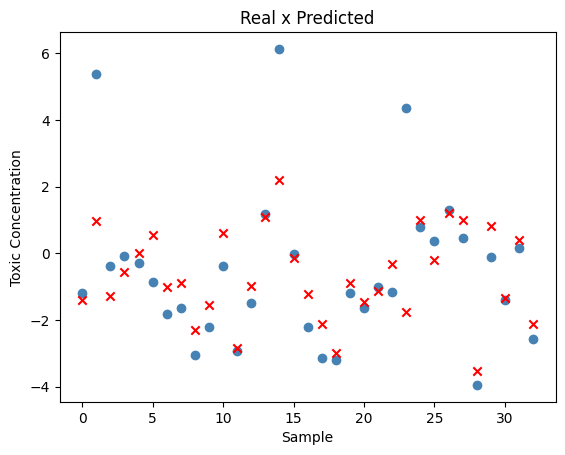

In [174]:
# Model creation
L2 = Ridge(alpha=1)

# Model training
L2.fit(X_train_clean, y_train_clean)

# Prediction ingoring atypical samples
y_l2_pred = L2.predict(X_val)

plt.scatter(range(0,np.shape(y_val)[0]), y_val, color='steelblue', marker='o', label='Real')
plt.scatter(range(0,np.shape(y_l2_pred)[0]), y_l2_pred, color='red', marker='x', label='Predicted')
plt.title('Real x Predicted')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')

print("Sum of squares error mean :", mean_squared_error(y_val, y_l2_pred))
print('Performance = ',r2_score(y_val, y_l2_pred))
print('Number of features after regularization = %d ' % (np.count_nonzero(L2.coef_)))
print(L2.coef_)

### L1 + L2 Regularization

Let's try the Elastic Net regularization :

Sum of squares error mean : 2.499849556555522
Performance =  0.5112999701116322
Number of features after regularization = 4 


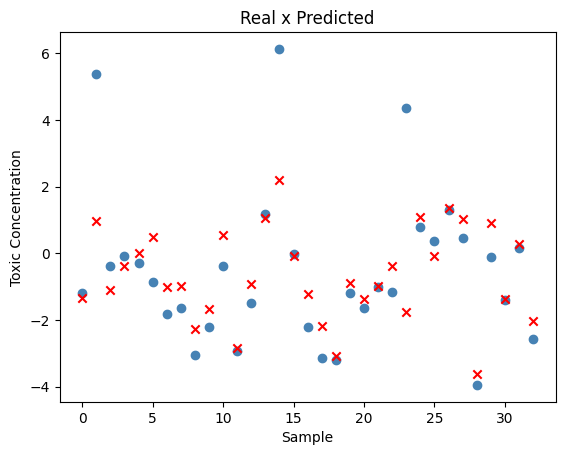

In [175]:
# Model creation
elastNet = ElasticNet(alpha=0.5, l1_ratio=0.3) #alpha controla el grado de regularización

# Model training
elastNet.fit(X_train_clean, y_train_clean)

# Prediction ingoring atypical samples
y_elas_pred = elastNet.predict(X_val)


plt.scatter(range(0,np.shape(y_val)[0]), y_val, color='steelblue', marker='o', label='Real')
plt.scatter(range(0,np.shape(y_elas_pred)[0]), y_elas_pred, color='red', marker='x', label='Predicted')
plt.title('Real x Predicted')
plt.ylabel('Toxic Concentration')
plt.xlabel('Sample')

print("Sum of squares error mean :", mean_squared_error(y_val, y_elas_pred))
print('Performance = ',r2_score(y_val, y_elas_pred))
print('Number of features after regularization = %d ' % (np.count_nonzero(elastNet.coef_)))


All of these regularization techniques slightly improved the performance of our model, but the improvement was not substantial.

## Removing the outliers - RANSAC Algorithm

In [176]:
ransac = RANSACRegressor(LinearRegression(), max_trials=150, min_samples=None, #número mínimo de muestras a considerar típicas
                         loss='absolute_error', residual_threshold=6, #Método para calcular el error y el umbral para considerar una muestra como típica
                        )
ransac.fit(X_train_clean, y_train_clean)
#Nuevamente ransac espera una matriz, no un array, por tanto convertimos a matriz de una columna

RANSACRegressor(estimator=LinearRegression(), max_trials=150,
                residual_threshold=6)

In [177]:
# We find the "atypical" samples 
typic_sample_mask = ransac.inlier_mask_ #Typical samples
atypic_sample_mask = np.logical_not(typic_sample_mask) #Atypical samples

# We locate those samples 
typic_sample_position = np.where(typic_sample_mask)[0]
atypic_sample_position = np.where(atypic_sample_mask)[0]


# We point to them
plt.scatter(typic_sample_position, y_train[typic_sample_mask],
            c='blue', edgecolor='white', marker='o', label='Typical')
plt.scatter(atypic_sample_position, y_train[atypic_sample_mask],
            c='red', edgecolor='white', marker='x', label='Atypical')

plt.title('Typical/Atypical samples distribution according to RANSAC')
plt.ylabel('Toxic Concentration')   
plt.xlabel('Sample')
plt.legend(loc="upper center")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 200 but corresponding boolean dimension is 132

Now, we have found those conflicting samples, we are going to remove them from the training set and meassure the model performance. 

In [178]:
y_train_pred_ransac = ransac.predict(X_train[typic_sample_position,:])

In [179]:
print(f"\t y = {ransac.estimator_.intercept_:.4f} + {ransac.estimator_.coef_[0]:.4f}x_1 + {ransac.estimator_.coef_[1]:.4f}x_2 + {ransac.estimator_.coef_[2]:.4f}x_3 + {ransac.estimator_.coef_[3]:.4f}x_4 + {ransac.estimator_.coef_[4]:.4f}x_5")

	 y = 8.3973 + -0.0017x_1 + 0.0068x_2 + -0.0004x_3 + -0.0020x_4 + -0.0656x_5


Our linear regression model without outliers is : $\newline$ 
$$y = \beta_0 + \beta_1x_{1} + \beta_2x_2 + \beta_3x_3 + \beta_4x_4 + \beta_5x_5$$

$$y = 1.2783 - 0.0053 \times x_{1} - 0.0085 \times x_2 - 0.0006 \times x_3 - 0.0047 \times x_4 + 0.0037 \times x_5$$

1.3804763932589184


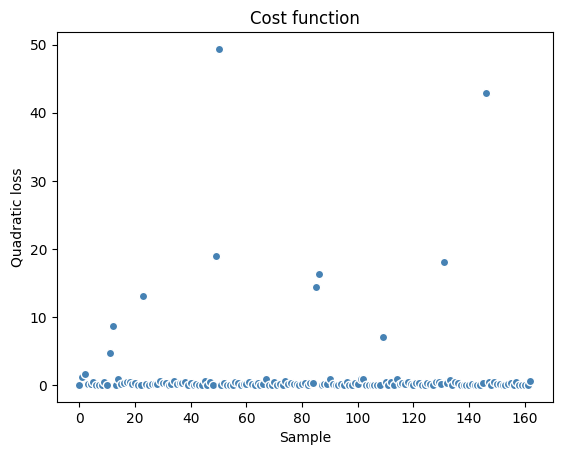

In [180]:
quadratic_loss = (y_train_pred_ransac - y_train[typic_sample_position])**2

plt.scatter(range(0,quadratic_loss.shape[0]), quadratic_loss, c='steelblue', marker='o',
            edgecolor='white', label='Entrenamiento')

plt.title('Cost function')
plt.ylabel('Quadratic loss')
plt.xlabel('Sample')

print(quadratic_loss.mean())

### Score

In [181]:
print(mean_squared_error(y_train[typic_sample_position], y_train_pred_ransac))
print(r2_score(y_train[typic_sample_position], y_train_pred_ransac))

1.3804763932589184
0.583172288338194
